In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools
from matplotlib.lines import Line2D
import mpmath

### Simulation répartition aléatoire du nb de mutations

In [3]:
# Define parameters
num_positions = 316  # Total positions
total_mutations = 79  # Total number of mutations
num_simulations = 10000  # Number of simulations

# Weighted probabilities based on observed substitution rates
#codon_position_weights = [0.25, 0.15, 0.60]  # 1st, 2nd, 3rd

# Pick a codon at random, then mutate one position based on the weights
#gene_codons = 312 // 3
#mutation_positions = []

#for _ in range(n_mutations):
#    codon_index = np.random.randint(0, gene_codons)
#    codon_pos = np.random.choice([0, 1, 2], p=codon_position_weights)
#    mutation_pos = codon_index * 3 + codon_pos
#    mutation_positions.append(mutation_pos)


# Load sequence coverage data from CSV
coverage_df = pd.read_csv("../data/Mutations/WeightPositions_TRA_sim.csv")
sequence_coverage = coverage_df["Coverage"].values

# Normalize coverage to get probabilities
mutation_probabilities = sequence_coverage / sequence_coverage.sum()

# Generate all simulations at once using weighted probabilities
simulations = np.array([
    np.random.multinomial(total_mutations, mutation_probabilities) for _ in range(num_simulations)
]).T

# Create DataFrame
positions = np.arange(1, num_positions + 1)
columns = [f"Simulation_{i+1}" for i in range(num_simulations)]
mutation_df = pd.DataFrame(simulations, columns=columns)
mutation_df.insert(0, "Position", positions)
mutation_df.insert(1, "Coverage", sequence_coverage)

# Calculate mean and standard error for each position
#mutation_df['Mean_Mutations'] = mutation_df.iloc[:, 2:].mean(axis=1)
#mutation_df['Std_Error'] = mutation_df.iloc[:, 2:].sem(axis=1)

# Calculate normalized sum of mutations per position
#mutation_df['Normalized_Sum'] = mutation_df.iloc[:, 2:].sum(axis=1) / num_simulations

# Save to CSV (optional)
mutation_df.to_csv("../data/Mutations/random_mutations_10000_simulations_TRA.csv", index=False)

# Display first few rows
mutation_df.head()


,Position,Coverage,Simulation_1,Simulation_2,Simulation_3,Simulation_4,Simulation_5,Simulation_6,Simulation_7,Simulation_8,...,Simulation_9991,Simulation_9992,Simulation_9993,Simulation_9994,Simulation_9995,Simulation_9996,Simulation_9997,Simulation_9998,Simulation_9999,Simulation_10000
0,1,93,0,0,0,0,0,0,0,0,...,2,1,0,0,0,0,0,0,0,1
1,2,93,1,1,1,0,0,0,1,0,...,0,1,1,1,0,0,1,1,0,0
2,3,93,1,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,4,93,0,0,0,0,1,0,2,0,...,0,0,1,1,1,2,0,0,0,2
4,5,93,1,0,0,0,0,0,0,0,...,2,1,1,0,1,0,1,0,0,0


## Calculate probabililty

In [4]:
# Load real data
real_df = pd.read_csv("../data/Mutations/GeneV_mutations_positions_TRA.csv")  # Adjust path
real_mutations = real_df["Total TRA"].values

# Load simulated mutation data
sim_df = pd.read_csv("../data/Mutations/random_mutations_10000_simulations_TRA.csv")
# Get only the simulation columns as a NumPy array
simulation_data = sim_df.filter(like="Simulation_").values


# Sanity check
num_positions=316
assert len(real_mutations) == num_positions, "Mismatch in number of positions"

p_values = []
for i in range(num_positions):
    simulated_counts = simulation_data[i]
    real_count = real_mutations[i]
    p = np.mean(simulated_counts >= real_count)
    p_values.append(p)

# Add real mutations and p-values to the mutation_df (which you can reload or reuse)
mutation_df = sim_df.copy()
mutation_df['Real_Mutations'] = real_mutations
mutation_df['P_Value'] = p_values

#Multiple testing correction
mutation_df['Adjusted_P'] = multipletests(mutation_df['P_Value'], method='fdr_bh')[1]

# Save the result
mutation_df.to_csv("../data/Mutations/mutation_comparison_with_pvalues_10000sim_TRA.csv", index=False)


## Statistics on region

In [7]:
# Load real data
real_df = pd.read_csv("../data/Mutations/GeneV_mutations_positions_TRA.csv")  # Adjust path
real_mutations = real_df["Total TRA"].values

# Load simulated mutation data
sim_df = pd.read_csv("../data/Mutations/random_mutations_10000_simulations_TRA.csv")
# Get only the simulation columns as a NumPy array
simulation_data = sim_df.filter(like="Simulation_").values

# Set the precision (number of decimal places)
mpmath.mp.dps = 50  # 50 decimal places

##Define region
# List of tuples: (region_name, start_pos, end_pos)
regions = [
    ("Region_1", 0, 80),
    ("Region_2", 81, 116),
    ("Region_3", 117, 167),
    ("Region_4", 168, 197),
    ("Region_5", 198, 315)
]

## Compute Real and Simulated Mutation Totals per Region
region_results = []

for name, start, end in regions:
    indices = list(range(start, end + 1))
    region_length = len(indices)

    # Real data
    real_sum = real_mutations[indices].sum()

    # Simulations
    sim_sums = simulation_data[indices, :].sum(axis=0)

    # Convert to mpmath format
    real_sum_mp = mpmath.mpf(str(real_sum))
    sim_sums_mp = [mpmath.mpf(str(s)) for s in sim_sums]

    # Calculate p-value using higher precision
    count = sum(1 for s in sim_sums_mp if s >= real_sum_mp)
    p_val = float(count / len(sim_sums_mp))
    
    # Empirical p-value
    #p_val = np.mean(sim_sums >= real_sum)


    region_results.append({
        "Region": name,
        "Start": start,
        "End": end,
        "Length": region_length,
        "Real_Mutations": real_sum,
        "Mean_Simulated": sim_sums.mean(),
        "P_Value": p_val,
        "Simulated_Distribution": sim_sums  # keep for later pairwise tests
    })

##Multiple Testing Correction

p_vals = [r["P_Value"] for r in region_results]
adjusted_p = multipletests(p_vals, method='fdr_bh')[1]

for i, adj_p in enumerate(adjusted_p):
    region_results[i]["Adjusted_P"] = adj_p


# Format p-values in scientific notation
#for result in region_results:
#    result["P_Value_Scientific"] = f"{result['P_Value']:.2e}"
#    result["Adjusted_P_Scientific"] = f"{result['Adjusted_P']:.2e}"

# --- Save region vs simulation results ---
region_df = pd.DataFrame([{
    "Region": r["Region"],
    "Start": r["Start"],
    "End": r["End"],
    "Length": r["Length"],
    "Real_Mutations": r["Real_Mutations"],
    "Mean_Simulated": r["Mean_Simulated"],
    "P_Value": r["P_Value"],
    "Adjusted_P": r["Adjusted_P"]
} for r in region_results])

region_df.to_csv("../data/Mutations/region_vs_simulation_results_TRA_10000.csv", index=False)

# --- Region vs region empirical comparison ---
def empirical_region_comparison(region_a, region_b):
    sim_a = region_a["Simulated_Distribution"] / region_a["Length"]
    sim_b = region_b["Simulated_Distribution"] / region_b["Length"]
    
    real_density_a = region_a["Real_Mutations"] / region_a["Length"]
    real_density_b = region_b["Real_Mutations"] / region_b["Length"]
    real_diff = real_density_a - real_density_b

    sim_diff = sim_a - sim_b
    p_empirical = np.mean(np.abs(sim_diff) >= np.abs(real_diff))

    return real_density_a, real_density_b, real_diff, p_empirical

# --- All pairwise comparisons ---
pairwise_results = []
for region_a, region_b in itertools.combinations(region_results, 2):
    dens_a, dens_b, diff, pval = empirical_region_comparison(region_a, region_b)
    pairwise_results.append({
        "Region_A": region_a["Region"],
        "Region_B": region_b["Region"],
        "Density_A": dens_a,
        "Density_B": dens_b,
        "Density_Difference": diff,
        "Empirical_P": pval
    })

# Extract p-values for multiple testing correction
p_vals_pairwise = [r["Empirical_P"] for r in pairwise_results]
adjusted_p_pairwise = multipletests(p_vals_pairwise, method='fdr_bh')[1]

# Add adjusted p-values to the pairwise results
for i, adj_p in enumerate(adjusted_p_pairwise):
    pairwise_results[i]["Adjusted_P"] = adj_p


# --- Save region vs region comparison ---
pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df.to_csv("../data/Mutations/region_vs_region_comparison_TRA_10000.csv", index=False)

print("Analysis complete. Results saved to:")
print("region_vs_simulation_results.csv")
print("region_vs_region_comparison.csv")


Analysis complete. Results saved to:
region_vs_simulation_results.csv
region_vs_region_comparison.csv


## Visualisation with simulation and mutations

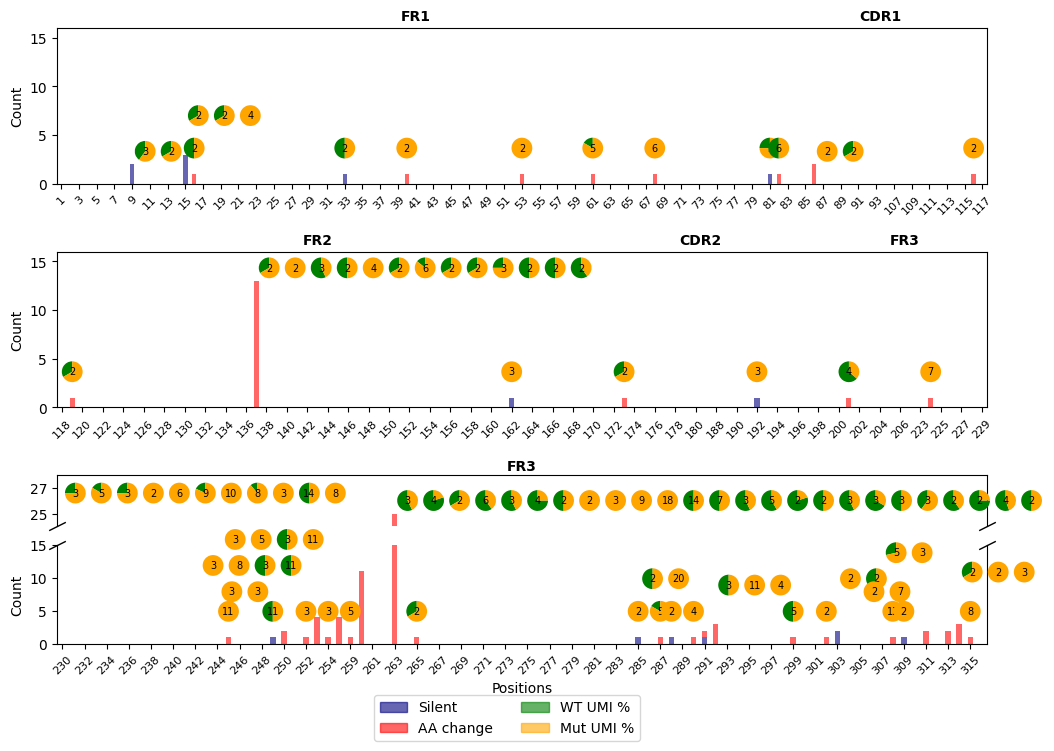

In [29]:
file_path_1 = "../data/Mutations/WeightPositions_TRA_sim.csv"
file_path_2 = "../data/Mutations/GeneV_mutations_positions_TRA.csv"

df1 = pd.read_csv(file_path_1)
df2 = pd.read_csv(file_path_2)

filtered_df1 = df1[df1['Coverage'] != 0]
merged_df = pd.merge(df2, filtered_df1[['Positions']], on='Positions', how='inner')

ref_cols = [c for c in merged_df.columns if c.startswith('UMI Ref')]
mut_cols = [c for c in merged_df.columns if c.startswith('UMI Mut')]

region_bounds = [
    ("FR1", 1, 81), ("CDR1", 82, 117), ("FR2", 118, 168),
    ("CDR2", 169, 198), ("FR3", 199, 316),
]

ranges = [(1, 117), (118, 229), (230, 316)]
horizontal_positions = {9, 15, 86, 137, 250, 253, 255, 260, 263, 291, 292, 303, 311, 313, 314}   # only these get the single-line side layout
# stacking order (low -> high) for the ones that sit close together and need a cascade
horizontal_tier = {9: 0, 15: 1, 86: 0, 250: 1, 253: 1.5, 255: 2.5, 260: 2.5, 137: 0, 263: 0, 291: 1.5, 292: 1, 
                   303: 1.5, 311: 1, 313: 2.5, 314: 1.5}
bar_width = 0.5
circle_size = 0.26   # inches
gap_factor = 1       # extra breathing room between circles
ncols_max = 4         # circles per row before wrapping to a new row

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(8, 1, height_ratios=[1, 0.2, 1, 0.2, 0.2, 0.01, 0.02, 0.5], hspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[2])
ax3_top = fig.add_subplot(gs[4:6])
ax3_bottom = fig.add_subplot(gs[6:])
axes = [ax1, ax2]

# fixed ylims, matching the original reference plot (kept constant regardless of cluster size,
# since clusters are now laid out as a single horizontal line and simply extend sideways instead)
ax1.set_ylim(0, 16)
ax2.set_ylim(0, 16)
ax3_bottom.set_ylim(0, 15)
ax3_top.set_ylim(24, 28)
ax3_top.set_yticks([25, 27])
fig.canvas.draw()

def axis_constants(ax, xlim):
    """Return (Cx, Cy) such that dx = Cx*xrange, dy = Cy*yrange give the data-unit
    footprint of one circle (in that axis) for the *current* figure layout."""
    bbox = ax.get_window_extent()
    circle_px = circle_size * fig.dpi * gap_factor
    Cx = circle_px / bbox.width
    Cy = circle_px / bbox.height
    return Cx, Cy

def cluster_layout(n, ncols_max=ncols_max):
    # user wants one single horizontal line per cluster, however long
    return n, 1

# ------------------------------------------------------------------
# Pass 1: figure out, per axis, how many stacked rows are needed at worst,
# and pre-compute per-position layout info.
# ------------------------------------------------------------------
plan = {}  # position index (within its subset) -> dict(...)
axis_max_rows = {}

for i, (start, end) in enumerate(ranges):
    mask = (merged_df['Positions'] >= start) & (merged_df['Positions'] <= end)
    subset = merged_df[mask].reset_index(drop=True)
    x_indexes = np.arange(len(subset))
    silent_vals = subset['Silent TRA']
    aa_vals = subset['AA change TRA']
    heights = (silent_vals + aa_vals).values

    for j in range(len(subset)):
        active = [(subset[r][j], subset[m][j]) for r, m in zip(ref_cols, mut_cols)
                  if subset[r][j] + subset[m][j] > 0]
        n = len(active)
        if n == 0:
            continue
        ncols, nrows = cluster_layout(n)
        key = (i, j)
        plan[key] = dict(active=active, ncols=ncols, nrows=nrows, height=heights[j])

# max rows needed per axis (ax1, ax2, ax3_bottom-lowheight, ax3_top-highheight)
for key, info in plan.items():
    i, j = key
    axis_id = i if i < 2 else ('ax3_top' if info['height'] >= 20 else 'ax3_bottom')
    axis_max_rows[axis_id] = max(axis_max_rows.get(axis_id, 1), info['nrows'])

# dx/dy footprint of one circle, computed once against the fixed axis ranges above
Cx1, _ = axis_constants(ax1, ax1.get_xlim())
Cx2, _ = axis_constants(ax2, ax2.get_xlim())
Cxb, _ = axis_constants(ax3_bottom, ax3_bottom.get_xlim())
Cxt, _ = axis_constants(ax3_top, ax3_top.get_xlim())
_, Cy1 = axis_constants(ax1, ax1.get_xlim())
_, Cy2 = axis_constants(ax2, ax2.get_xlim())
_, Cyb = axis_constants(ax3_bottom, ax3_bottom.get_xlim())
_, Cyt = axis_constants(ax3_top, ax3_top.get_xlim())

def draw_bar_and_get_heights(ax, x_indexes, silent_vals, aa_vals):
    ax.bar(x_indexes, silent_vals, width=bar_width, color='navy', alpha=0.6)
    ax.bar(x_indexes, aa_vals, width=bar_width, color='red', alpha=0.6, bottom=silent_vals)

def draw_cluster(ax, x, base_height, active, dx, dy, direction, tier=0):
    """Draw a single horizontal line of pies anchored near (x, base_height),
    growing right, left, or centered. `tier` raises the whole line by tier*dy,
    used to cascade nearby clusters (e.g. 253 lower than 255 lower than 260)."""
    n = len(active)
    ncols, nrows = cluster_layout(n)
    gap = dx * 0.15
    if direction == 'left':
        col_x = [x - (ncols - c) * dx for c in range(ncols)]
    elif direction == 'right':
        col_x = [x + 0.5 * dx + c * dx for c in range(ncols)]
    else:  # center
        col_x = [x - (ncols - 1) / 2 * dx + c * dx for c in range(ncols)]

    base_y = base_height + dy * 0.5 + tier * dy
    idx = 0
    xs_used, ys_used = [], []
    for row in range(nrows):
        y = base_y + row * dy
        for c in range(ncols):
            if idx >= n:
                break
            r, m = active[idx]
            cx = col_x[c]
            axins = inset_axes(ax, width=circle_size, height=circle_size, loc='center',
                                bbox_to_anchor=(cx, y), bbox_transform=ax.transData, borderpad=0)
            axins.pie([r, m], colors=['green', 'orange'], startangle=90)
            axins.set_aspect('equal')
            axins.text(0, 0, str(m), ha='center', va='center', fontsize=7, color='black')
            axins.axis('off')
            xs_used.append(cx); ys_used.append(y)
            idx += 1

# ------------------------------------------------------------------
# Pass 2: actually draw everything
# ------------------------------------------------------------------
for i, (start, end) in enumerate(ranges):
    mask = (merged_df['Positions'] >= start) & (merged_df['Positions'] <= end)
    subset = merged_df[mask].reset_index(drop=True)
    x_indexes = np.arange(len(subset))
    silent_vals = subset['Silent TRA']
    aa_vals = subset['AA change TRA']
    heights = (silent_vals + aa_vals).values

    if i < 2:
        ax = axes[i]
        draw_bar_and_get_heights(ax, x_indexes, silent_vals, aa_vals)
        dx, dy = (Cx1 * len(x_indexes), Cy1 * (ax.get_ylim()[1] - ax.get_ylim()[0])) if i == 0 else \
                 (Cx2 * len(x_indexes), Cy2 * (ax.get_ylim()[1] - ax.get_ylim()[0]))

        for j, x in enumerate(x_indexes):
            key = (i, j)
            if key not in plan:
                continue
            info = plan[key]
            n = len(info['active'])
            pos_val = subset['Positions'][j]
            if pos_val not in horizontal_positions:
                for k, (r, m) in enumerate(info['active']):
                    y_pos = heights[j] + dy * (k + 1)
                    axins = inset_axes(ax, width=circle_size, height=circle_size, loc='center',
                                        bbox_to_anchor=(x, y_pos), bbox_transform=ax.transData, borderpad=0)
                    axins.pie([r, m], colors=['green', 'orange'], startangle=90)
                    axins.set_aspect('equal')
                    axins.text(0, 0, str(m), ha='center', va='center', fontsize=7, color='black')
                    axins.axis('off')
            else:
                footprint = info['ncols'] * dx
                window = subset[(subset.index > j) & (subset.index <= j + max(1, int(footprint)))]
                right_h = window['Silent TRA'].add(window['AA change TRA'], fill_value=0).max() if len(window) else 0
                direction = 'left' if (pd.notna(right_h) and right_h > heights[j]) else 'right'
                draw_cluster(ax, x, heights[j], info['active'], dx, dy, direction,
                             tier=horizontal_tier.get(pos_val, 0))

        ax.set_xlim(-0.5, len(subset) - 0.5)
        ax.set_xticks(x_indexes[::2])
        ax.set_xticklabels(subset['Positions'][::2], rotation=45, fontsize=8)
        ax.set_ylabel("Count")

        for name, r_start, r_end in region_bounds:
            in_region = subset[(subset['Positions'] >= r_start) & (subset['Positions'] <= r_end)]
            if len(in_region) == 0:
                continue
            idxr = in_region.index
            center = (idxr.min() + idxr.max()) / 2
            ax.text(center, 1.03, name, ha='center', va='bottom', fontsize=10, fontweight='bold',
                    transform=ax.get_xaxis_transform())

    else:
        for ax in (ax3_bottom, ax3_top):
            draw_bar_and_get_heights(ax, x_indexes, silent_vals, aa_vals)

        for j, x in enumerate(x_indexes):
            key = (i, j)
            if key not in plan:
                continue
            info = plan[key]
            n = len(info['active'])
            ax_use = ax3_top if heights[j] >= 20 else ax3_bottom
            dx = (Cxt if ax_use is ax3_top else Cxb) * len(x_indexes)
            dy = (Cyt if ax_use is ax3_top else Cyb) * (ax_use.get_ylim()[1] - ax_use.get_ylim()[0])

            pos_val = subset['Positions'][j]
            if pos_val not in horizontal_positions:
                for k, (r, m) in enumerate(info['active']):
                    y_pos = heights[j] + dy * (k + 1)
                    axins = inset_axes(ax_use, width=circle_size, height=circle_size, loc='center',
                                        bbox_to_anchor=(x, y_pos), bbox_transform=ax_use.transData, borderpad=0)
                    axins.pie([r, m], colors=['green', 'orange'], startangle=90)
                    axins.set_aspect('equal')
                    axins.text(0, 0, str(m), ha='center', va='center', fontsize=7, color='black')
                    axins.axis('off')
            else:
                footprint = info['ncols'] * dx
                window = subset[(subset.index > j) & (subset.index <= j + max(1, int(footprint)))]
                right_h = window['Silent TRA'].add(window['AA change TRA'], fill_value=0).max() if len(window) else 0
                direction = 'left' if (pd.notna(right_h) and right_h > heights[j]) else 'right'
                draw_cluster(ax_use, x, heights[j], info['active'], dx, dy, direction,
                             tier=horizontal_tier.get(pos_val, 0))

        ax3_bottom.set_xlim(-0.5, len(subset) - 0.5)
        ax3_bottom.set_xticks(x_indexes[::2])
        ax3_bottom.set_xticklabels(subset['Positions'][::2], rotation=45, fontsize=8)
        ax3_bottom.set_ylabel("Count")

        ax3_top.set_xlim(-0.5, len(subset) - 0.5)
        ax3_top.set_ylabel("")
        ax3_top.spines.bottom.set_visible(False)
        ax3_bottom.spines.top.set_visible(False)
        ax3_top.tick_params(labeltop=False, top=False)
        ax3_top.tick_params(labelbottom=False, bottom=False)
        ax3_bottom.xaxis.tick_bottom()

        d = .5
        kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none",
                      color='k', mec='k', mew=1, clip_on=False)
        ax3_top.plot([0, 1], [0, 0], transform=ax3_top.transAxes, **kwargs)
        ax3_bottom.plot([0, 1], [1, 1], transform=ax3_bottom.transAxes, **kwargs)

        for name, r_start, r_end in region_bounds:
            in_region = subset[(subset['Positions'] >= r_start) & (subset['Positions'] <= r_end)]
            if len(in_region) == 0:
                continue
            idxr = in_region.index
            center = (idxr.min() + idxr.max()) / 2
            ax3_top.text(center, 1.03, name, ha='center', va='bottom', fontsize=10, fontweight='bold',
                         transform=ax3_top.get_xaxis_transform())

ax3_bottom.set_xlabel("Positions")

handles = [
    plt.Rectangle((0, 0), 1, 1, color='navy', alpha=0.6, label='Silent'),
    plt.Rectangle((0, 0), 1, 1, color='red', alpha=0.6, label='AA change'),
    patches.Wedge((0, 0), 0.1, 0, 180, color='green', alpha=0.6, label='WT UMI %'),
    patches.Wedge((0, 0), 0.1, 180, 360, color='orange', alpha=0.6, label='Mut UMI %')
]
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.savefig("../outputs/Figures/histogram_plot_TRA.svg", format="svg", dpi=500, bbox_inches='tight')
plt.show()